In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [2]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=housing.feature_names)
df["HousePrice"] = y

In [3]:
print("\n========== Dataset Preview ==========\n")
print(df.head())


========== Dataset Preview ==========

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


In [4]:
print("\n========== Dataset Shape ==========\n")
print(df.shape)



========== Dataset Shape ==========

(20640, 9)


In [5]:
print("\n========== Dataset Information ==========\n")
print(df.info())


========== Dataset Information ==========

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [6]:
print("\n========== Statistical Summary ==========\n")
print(df.describe())




========== Statistical Summary ==========

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude    HousePrice  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532     

In [7]:
print("\n========== Missing Values ==========\n")
print(df.isnull().sum())


========== Missing Values ==========

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


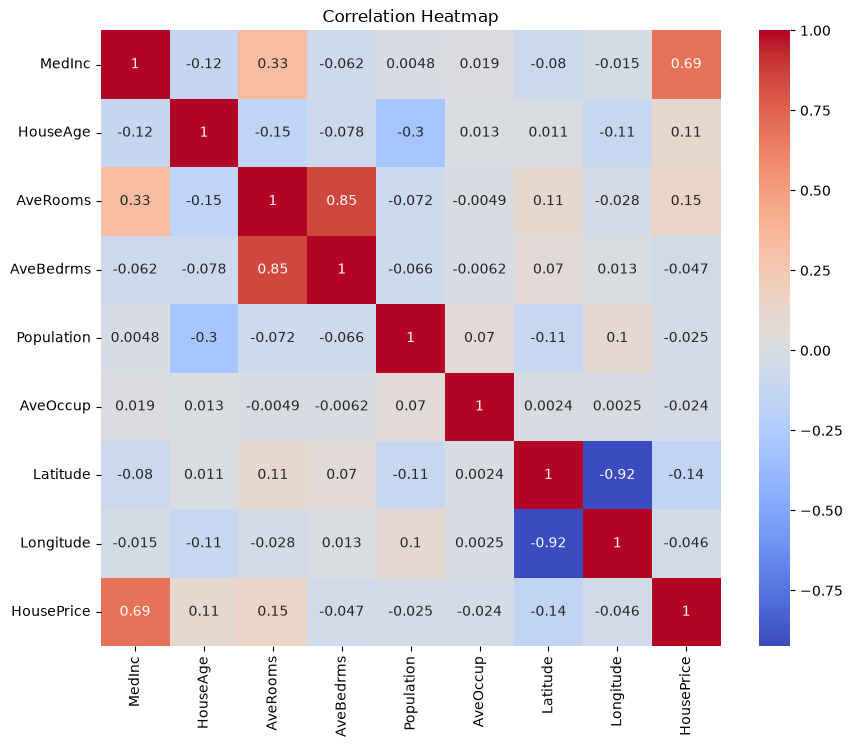

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [9]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = Sequential()

In [12]:
model.add(Dense(
    units=64,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

C:\Users\DEVAPRIYAN\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.add(Dense(
    units=32,
    activation='relu'
))

In [14]:
model.add(Dense(
    units=16,
    activation='relu'
))

In [15]:
model.add(Dense(
    units=1,
    activation='linear'
))

In [16]:
model.compile(
    optimizer=Adam(),
    loss='mse',
    metrics=['mae']
)

In [17]:
print("\n========== Model Summary ==========\n")
model.summary()


========== Model Summary ==========



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.7856 - mae: 0.6031 - val_loss: 0.4634 - val_mae: 0.4676
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3921 - mae: 0.4458 - val_loss: 0.4257 - val_mae: 0.4555
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3634 - mae: 0.4268 - val_loss: 0.4016 - val_mae: 0.4341
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3476 - mae: 0.4157 - val_loss: 0.3740 - val_mae: 0.4436
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3415 - mae: 0.4062 - val_loss: 0.3852 - val_mae: 0.4234
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3195 - mae: 0.3967 - val_loss: 0.3494 - val_mae: 0.4247
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3098 - mae: 0.3889 - val_loss: 0.3393 - val_mae: 0.4111
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3041 - mae: 0.3825 - val_loss: 0.3335 - val_mae: 0.4029
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

In [19]:
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step


In [20]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== Model Performance ==========\n")
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)



========== Model Performance ==========

Mean Absolute Error : 0.34463929724807885
Mean Squared Error  : 0.27612767940926103
Root Mean Squared Error : 0.5254785242131794
R2 Score : 0.7892812976755269


In [21]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

print("\n========== First 20 Actual vs Predicted ==========\n")
print(comparison.head(20))


========== First 20 Actual vs Predicted ==========

     Actual  Predicted
0   0.47700   0.520741
1   0.45800   0.905976
2   5.00001   4.640086
3   2.18600   2.591315
4   2.78000   2.789533
5   1.58700   1.574111
6   1.98200   2.188281
7   1.57500   1.599224
8   3.40000   2.187202
9   4.46600   4.946522
10  1.23200   1.173353
11  2.53900   2.123866
12  2.15100   1.500317
13  2.20500   1.660019
14  2.19800   2.583561
15  1.36200   1.638371
16  1.78400   2.001607
17  1.87500   1.563430
18  1.39800   1.497220
19  1.37500   1.127650


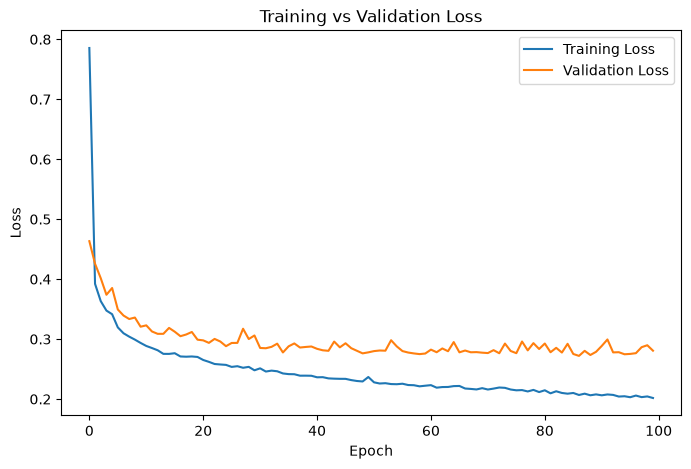

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

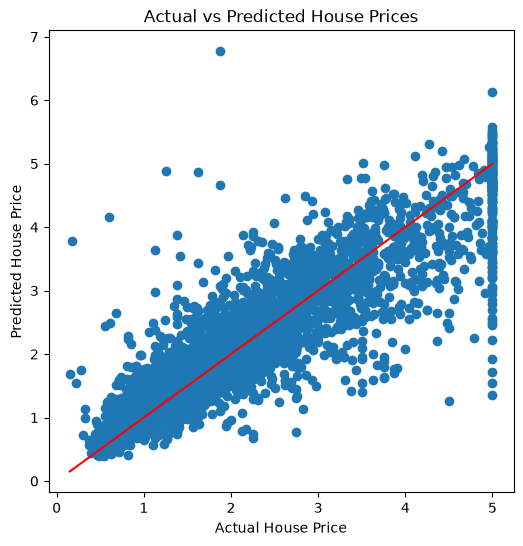

In [23]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

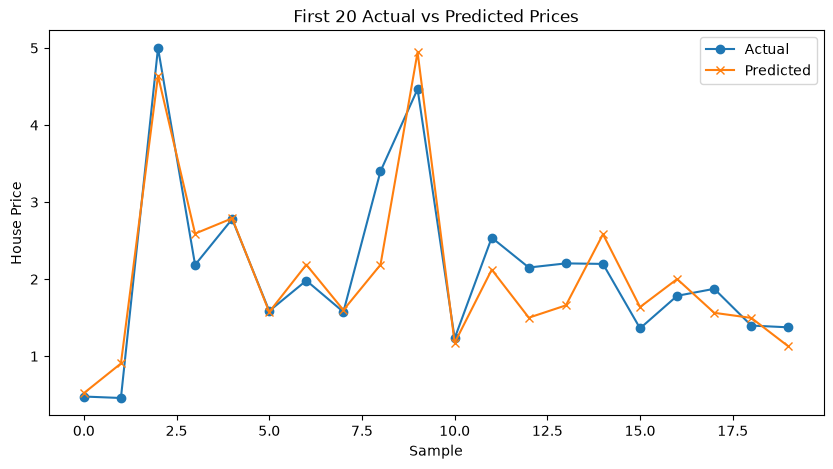

In [24]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:20], marker='o', label="Actual")
plt.plot(y_pred[:20], marker='x', label="Predicted")

plt.title("First 20 Actual vs Predicted Prices")
plt.xlabel("Sample")
plt.ylabel("House Price")
plt.legend()

plt.show()


In [25]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print("\n========== Sample House Prediction ==========\n")
print("Predicted House Price :", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

========== Sample House Prediction ==========

Predicted House Price : 0.5207408


In [26]:
model.save("HousePriceANN.keras")

print("\nModel Saved Successfully as HousePriceANN.keras")


Model Saved Successfully as HousePriceANN.keras
